# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [1]:
from acceptor_TI import Problem

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 2
hopping_dict["t_pp_pi"] = -3

In [3]:
problem.setup(
    size = 10, # size of lattice in real space
    N_k = 300, # reciprocal space discretization
)

Building Geometry...
Geometry - Done.
Building Hamiltonian...
Hamiltonian - Done.


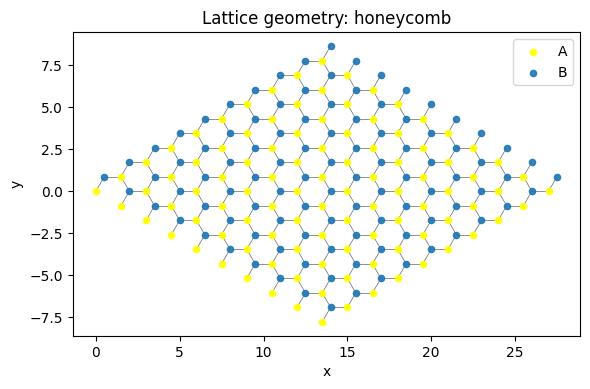

In [4]:
problem.plot(plot_type="lattice")

## Clebsch-Gordan Coefficients

In [5]:
tb = problem.tight_binding

tb.CB_state_key

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [6]:
tb.data_dict["A"].keys()

dict_keys(['idx', 'neighbour_idxs', 'dr_dict', 'hopping_dict', 'coupled_states_dict'])

In [7]:
tb.data_dict["A"]["neighbour_idxs"]

array([125, 127, 145])

## Coupled Angular Momentum States

In [8]:
idx = tb.data_dict["A"]["neighbour_idxs"][0]
tb.data_dict["A"]['coupled_states_dict'][idx]

{'|0.5,-0.5><0.5,-0.5|': -1.40000000000000,
 '|0.5,-0.5><1.5,-1.5|': -0.5*sqrt(2) - 4.44089209850063e-16*sqrt(2)*I,
 '|0.5,-0.5><1.5,-0.5|': 0,
 '|0.5,-0.5><1.5,0.5|': 0.166666666666667*sqrt(6) - 1.48029736616688e-16*sqrt(6)*I,
 '|0.5,0.5><0.5,0.5|': -1.40000000000000,
 '|0.5,0.5><1.5,-0.5|': -0.166666666666667*sqrt(6) - 1.48029736616688e-16*sqrt(6)*I,
 '|0.5,0.5><1.5,0.5|': 0,
 '|0.5,0.5><1.5,1.5|': 0.5*sqrt(2) - 4.44089209850063e-16*sqrt(2)*I,
 '|1.5,-1.5><0.5,-0.5|': 0.5*sqrt(2) + 4.44089209850063e-16*sqrt(2)*I,
 '|1.5,-1.5><1.5,-1.5|': 2.5 + 4.44089209850063e-15*I,
 '|1.5,-1.5><1.5,-0.5|': 0,
 '|1.5,-1.5><1.5,0.5|': 0.166666666666667*sqrt(3),
 '|1.5,-0.5><0.5,0.5|': 0.166666666666667*sqrt(6) + 1.48029736616688e-16*sqrt(6)*I,
 '|1.5,-0.5><1.5,-0.5|': -2.00000000000000,
 '|1.5,-0.5><1.5,0.5|': 0,
 '|1.5,-0.5><1.5,1.5|': 0.166666666666667*sqrt(3),
 '|1.5,-0.5><0.5,-0.5|': 0,
 '|1.5,-0.5><1.5,-1.5|': 0,
 '|1.5,0.5><0.5,0.5|': 0,
 '|1.5,0.5><1.5,-0.5|': 0,
 '|1.5,0.5><1.5,0.5|': 0.83333

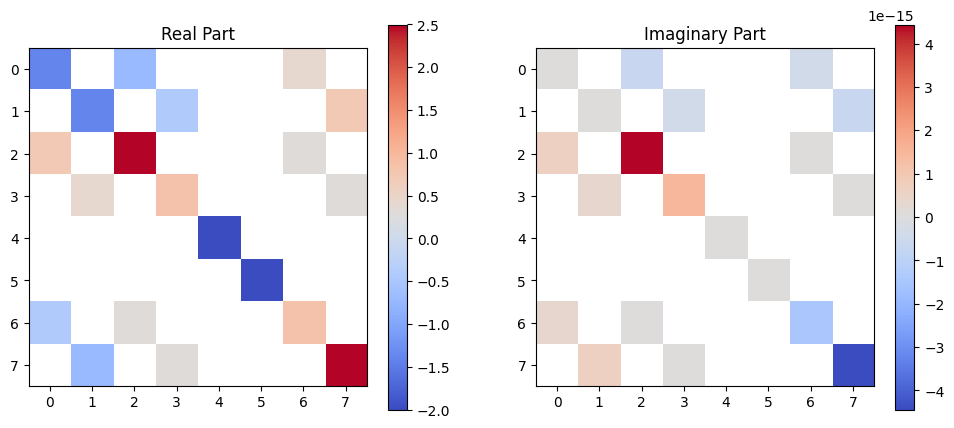

In [9]:
tb._visualise_matrix(tb.data_dict["A"]['hopping_dict'][idx])

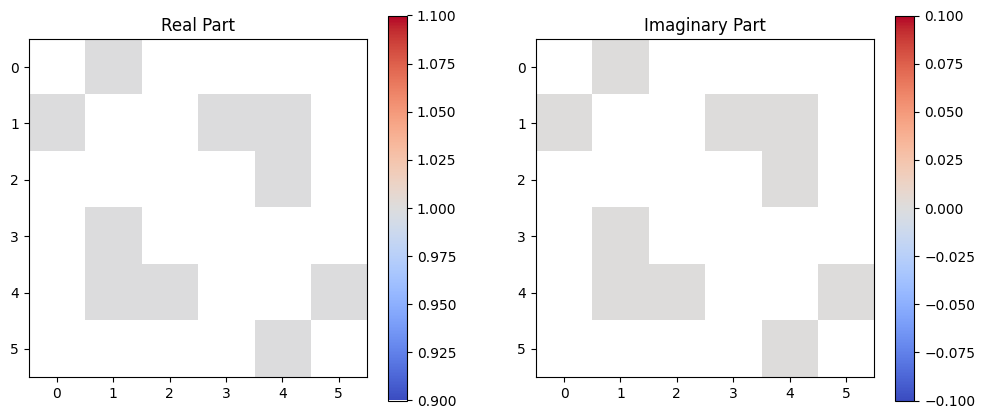

In [10]:
tb._visualise_matrix(tb.sublattice_connectivity)

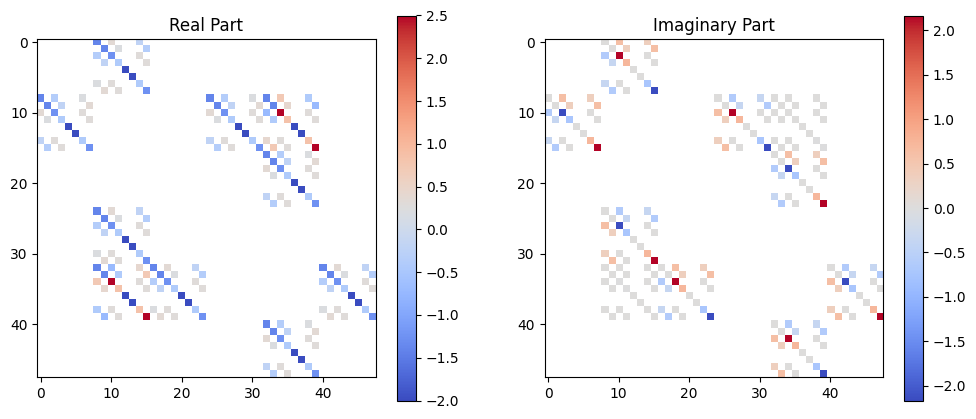

In [11]:
tb._visualise_matrix(tb.H)

In [12]:
problem.run(
    acceptor=False,
    H_type="real_space"
)

Calculating eigenvalues...
Eigenvalues - Done.


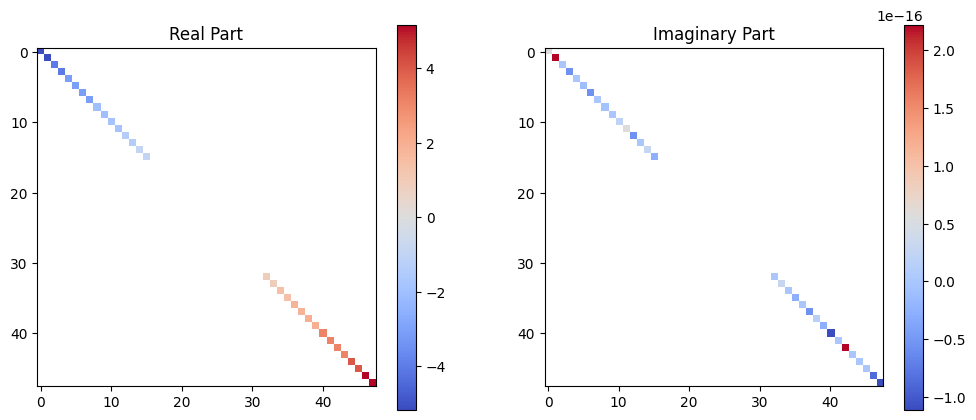

In [13]:
tb._visualise_matrix(tb.H_diag)

In [14]:
tb.E

array([-5.16492950e+00, -5.16492950e+00, -4.00000000e+00, -4.00000000e+00,
       -3.10530064e+00, -3.10530064e+00, -3.07370472e+00, -3.07370472e+00,
       -2.00000000e+00, -2.00000000e+00, -1.85205461e+00, -1.85205461e+00,
       -1.42677278e+00, -1.42677278e+00, -8.88473914e-01, -8.88473914e-01,
       -7.58179993e-16, -5.80809122e-16, -3.90277232e-16, -3.02154180e-16,
       -2.00481288e-16, -1.30407010e-16, -3.84952624e-17,  2.24342410e-17,
        4.74015129e-17,  1.03556978e-16,  2.02557394e-16,  2.83847656e-16,
        4.99239943e-16,  6.48517812e-16,  9.46472874e-16,  1.63571243e-15,
        8.88473914e-01,  8.88473914e-01,  1.42677278e+00,  1.42677278e+00,
        1.85205461e+00,  1.85205461e+00,  2.00000000e+00,  2.00000000e+00,
        3.07370472e+00,  3.07370472e+00,  3.10530064e+00,  3.10530064e+00,
        4.00000000e+00,  4.00000000e+00,  5.16492950e+00,  5.16492950e+00])